In [23]:
import cartopy.crs as ccrs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

## Data Processing

In [2]:
def format_rbg_string(rgbstring):
    """Transform a RGB string to a tuple of floats that matplotlib can understand"""
    rgbs = rgbstring.split(' ')
    rgbtup = tuple(float(rgb) for rgb in rgbs)
    return rgbtup

with open('./data/legend of biomes.txt', 'r') as f:
    lines = [ l.strip() for l in f.readlines()] # Remove endline characters and spaces
    
biome_names = lines[slice(0, len(lines), 2)] # Only use the biome names, not the colors
biome_names = [ ' '.join(l.split(' ')[1:]) for l in biome_names ] # Remove number in front of names
biome_rgbs = lines[slice(1, len(lines), 2)] # Filter out biome RGB colors
biome_rgbs = [format_rbg_string(rgbstr) for rgbstr in biome_rgbs]

biome_names

['Boreal decid forest',
 'Boreal ever forest',
 'Temp/boreal mix fo.',
 'Temp conifer forest',
 'Temp decid forest',
 'Temp broad ever fo.',
 'Temp mixed forest',
 'Trop season forest',
 'Trop rain forest',
 'Trop decid forest',
 'Moist savannas',
 'Dry savannas',
 'Tall grassland',
 'Dry grassland',
 'Xeric wood/shrub',
 'Arid shrub/steppe',
 'Desert',
 'Arctic/alpine tundra']

In [3]:
df_countries = pd.read_csv('./data/gridlist_pan_gfed_ISO3_UN_ecoregion.txt', sep='\\s+')
df_countries.head()

,Lon,Lat,GFED-region,Pan_2007,ISO3,UN,Ecoregion
0,-69.75,-55.25,5,Americas,CHL,152,4
1,-69.25,-55.25,5,Americas,CHL,152,4
2,-71.25,-54.75,5,Americas,CHL,152,4
3,-70.75,-54.75,5,Americas,CHL,152,4
4,-70.25,-54.75,5,Americas,CHL,152,4


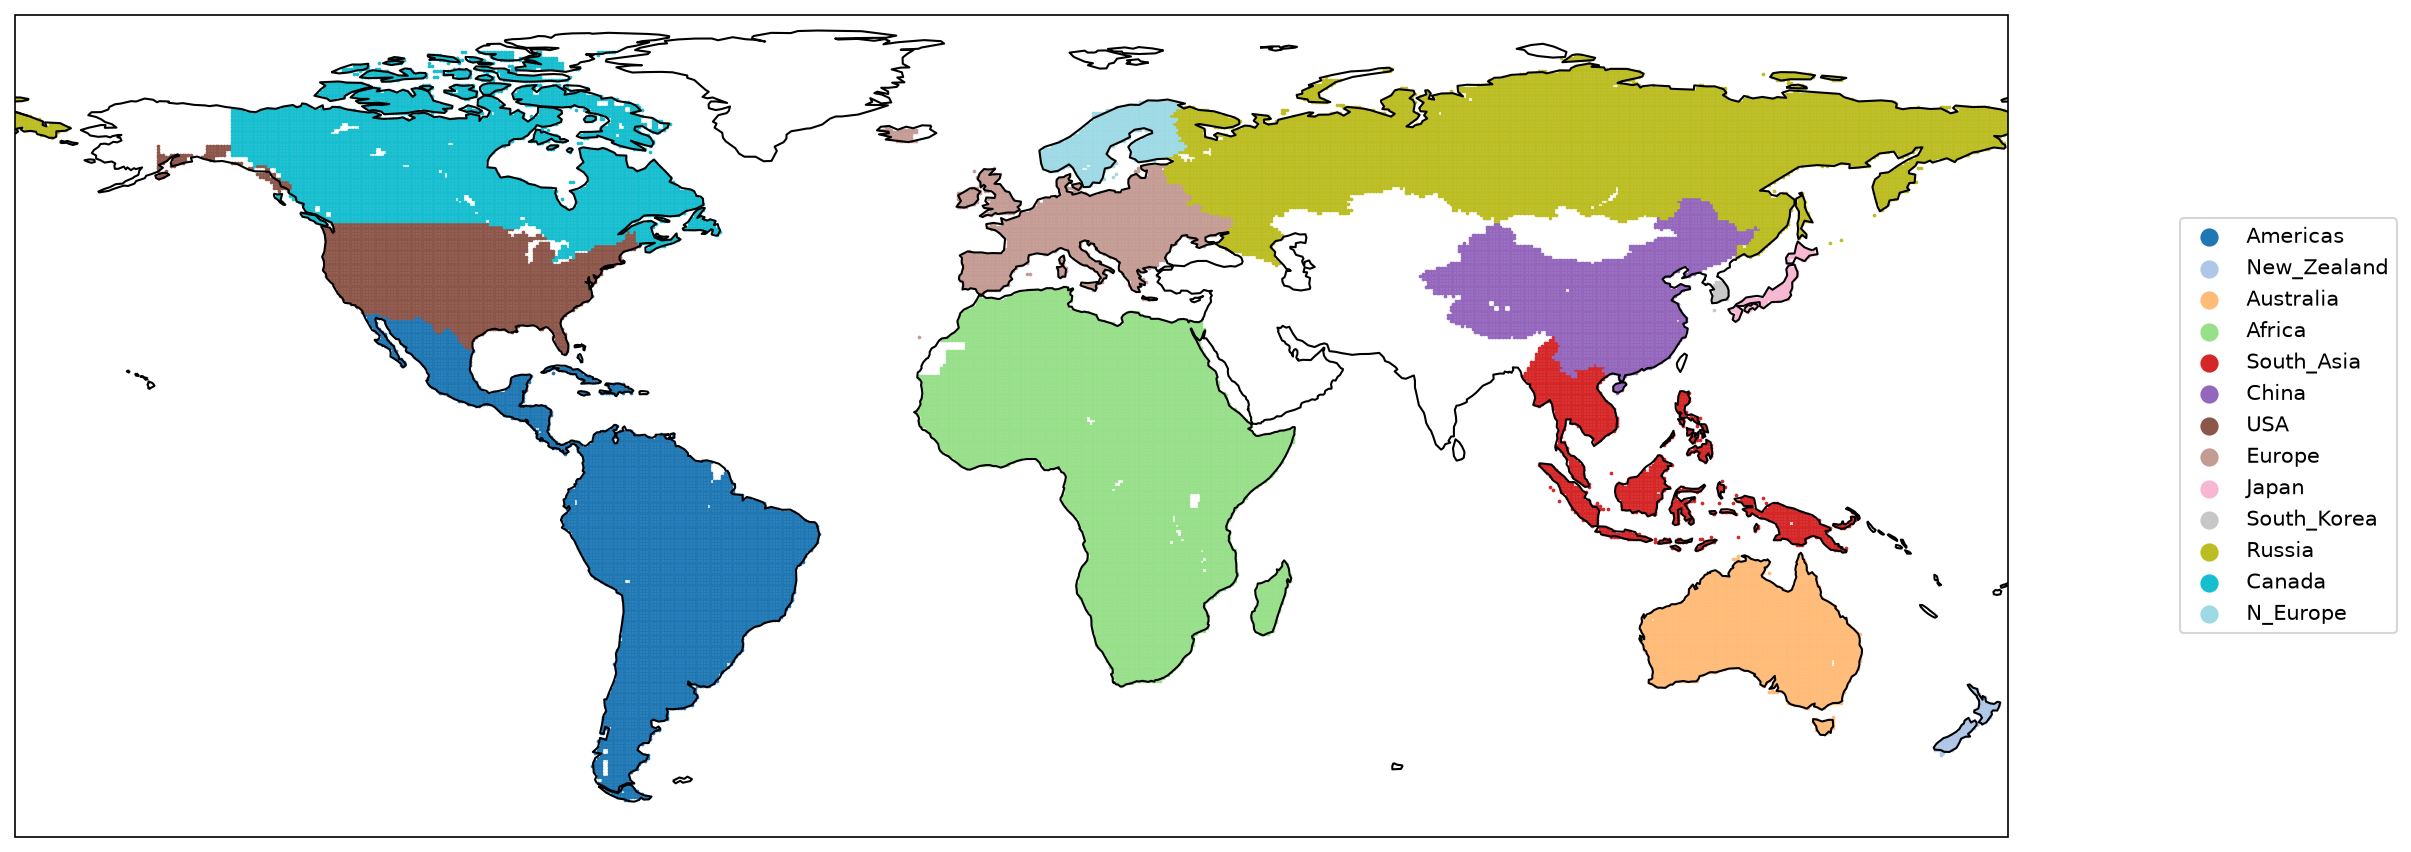

In [4]:
proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(16, 8), dpi=150, subplot_kw={"projection":proj})

countries = df_countries["Pan_2007"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(countries)))

for i, name in enumerate(countries):
    country = df_countries[df_countries["Pan_2007"] == name]
    ax.scatter(country["Lon"], country["Lat"], color=colors[i], s=0.6, label=name, transform=proj)

ax.legend(markerscale=10, loc='center right', bbox_to_anchor=(1.20, 0.5)) # Make markers bigger
ax.coastlines()  # type: ignore
plt.tight_layout()
plt.show()

In [5]:
region_mapping = {
    "Russia": "Russia",

    "Africa": "Africa",

    "Americas": "Latin_Americas",

    "Canada": "North_Americas",
    "USA": "North_Americas",

    "Australia": "Oceania",
    "New_Zealand": "Oceania",

    "Europe": "Europe",
    "N_Europe": "Europe",

    "South_Asia": "South_Asia",

    "Japan": "East_Asia",
    "South_Korea": "East_Asia",
    "China": "East_Asia"
}

df_countries["Region"] = (
    df_countries["Pan_2007"]
    .map(region_mapping)
)

df_countries["Region"].value_counts()

Region
Russia            11696
Africa            10164
North_Americas     9953
Latin_Americas     7176
East_Asia          3980
Europe             3229
Oceania            2961
South_Asia         1691
Name: count, dtype: int64

In [6]:
df_lpj = pd.read_csv('./data/LPJ-GUESS_output_BERN1.csv')
df_lpj.head()

,Lon,Lat,NPP,SoilR,MaxBiomeCmax,MaxBiomeLAI,VegC,LitterC,SoilC,Biome_Cmax,Biome_LAI,Biome_obs
0,39.75,-1.25,0.429,0.390,0.449,1.9821,1.225,0.758,5.941,8,12,12
1,150.25,-34.25,0.554,0.451,6.883,3.3174,6.953,3.221,10.566,7,7,6
2,-63.75,82.75,0.000,0.000,0.000,0.0000,0.000,0.003,0.002,13,13,17
3,59.25,30.75,0.043,0.042,0.090,0.2146,0.127,0.084,0.543,7,11,14
4,24.25,27.75,0.000,0.000,0.000,0.0000,0.000,0.000,0.000,13,13,17


In [7]:
biome_data = df_lpj[["Lon", "Lat", "Biome_obs"]]
biome_data["Biome_obs"].value_counts()

Biome_obs
2     11118
17     6505
9      5924
18     5725
16     4577
14     3965
5      3962
12     3643
15     3134
6      2748
8      2560
10     1702
1      1383
11     1027
3       734
13      367
7       117
Name: count, dtype: int64

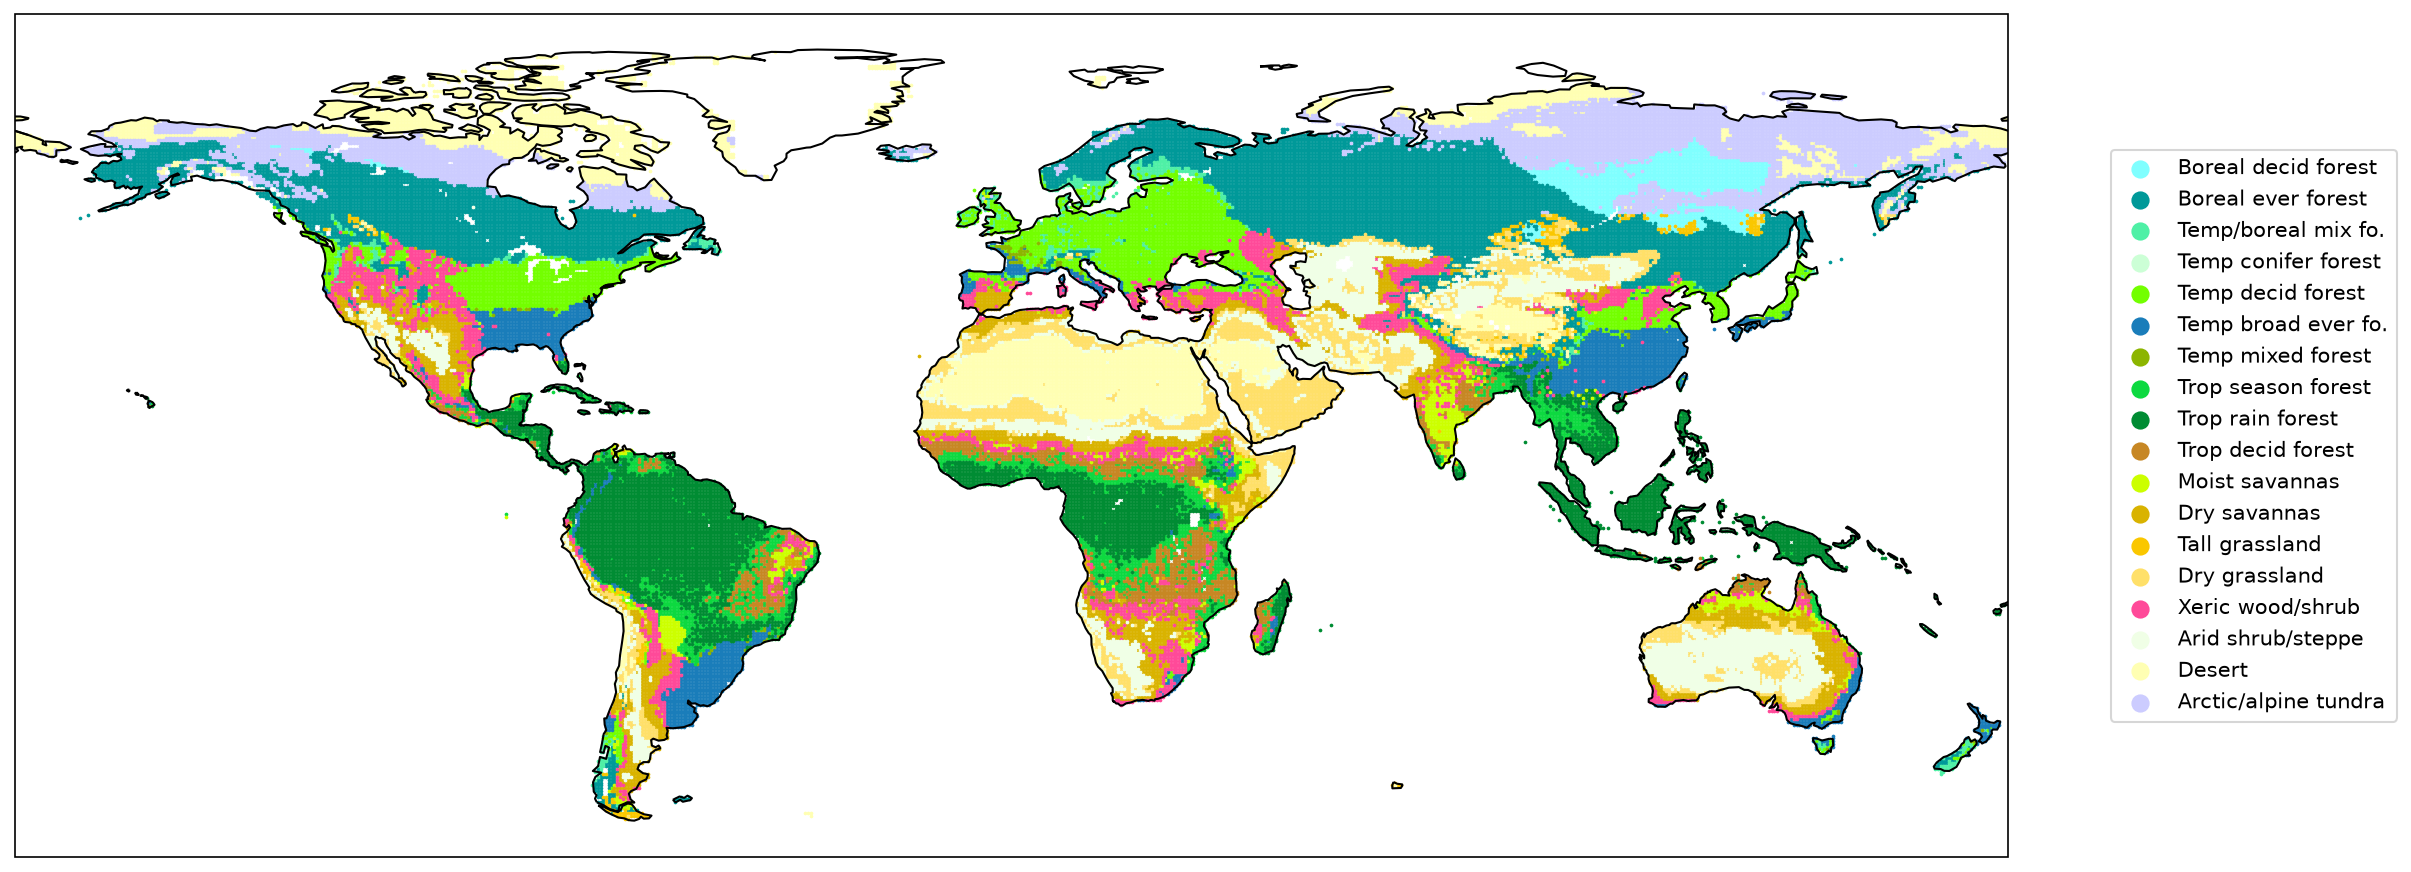

In [8]:
fig, ax = plt.subplots(figsize=(16, 8), dpi=150, subplot_kw={"projection":proj})

# Hacky way of creating a map, pretent it is a scatterplot with lons and lats on x and y!
for i, name in enumerate(biome_names):
    biome = biome_data[biome_data['Biome_obs'] == i + 1]
    biome.plot(x='Lon', y='Lat', color=biome_rgbs[i], ax=ax, kind='scatter', s=0.6, label=name, marker='o')

ax.legend(markerscale=10, loc='center right', bbox_to_anchor=(1.20, 0.5)) # Make markers bigger
ax.coastlines()  # type: ignore
plt.tight_layout()
plt.show()

In [9]:
file_dir = "./data/"
df_P = pd.read_csv(file_dir + "Predaymean1961_1990_stats.csv")
df_T_max = pd.read_csv(file_dir + "Tmaxdaymean1961_1990_stats.csv")
df_T_min = pd.read_csv(file_dir + "Tmindaymean1961_1990_stats.csv")
df_T_mean = pd.read_csv(file_dir + "Tmpdaymean1961_1990_stats.csv")
df_radiation = pd.read_csv(file_dir + "Tswrfdaymean1961_1990_stats.csv")
df_soil = pd.read_csv(file_dir + "soilmap.dat", sep=r"\s+")

In [10]:
df_soil.rename(columns={
    "lon": "Lon",
    "lat": "Lat",
}, inplace=True)

df_soil.head()

,Lon,Lat,clay,silt,sand,orgC,CN,pH,cellfraction
0,-179.75,71.25,0.08,0.37,0.55,0.020,11.0,5.9,0.482
1,-179.75,68.75,0.20,0.48,0.32,0.031,17.0,6.3,0.753
2,-179.75,68.25,0.20,0.48,0.32,0.031,17.0,6.3,0.447
3,-179.75,67.75,0.20,0.48,0.32,0.031,17.0,6.3,0.526
4,-179.75,67.25,0.20,0.48,0.32,0.031,17.0,6.3,0.422


## Data Analysis

In [11]:
dfs = [
    df_lpj,
    df_P,
    df_T_max,
    df_T_min,
    df_T_min,
    df_radiation,
    df_soil,
    df_countries
]

for df in dfs:
    print(df.shape)

(59191, 12)
(59191, 14)
(59191, 14)
(59191, 14)
(59191, 14)
(59191, 14)
(59191, 9)
(50850, 8)


In [12]:
for df in dfs:
    print(df[["Lon", "Lat"]].duplicated().sum())

0
0
0
0
0
0
0
0


In [13]:
coords = (
    df_lpj[["Lon", "Lat"]]
    .sort_values(["Lon", "Lat"])
    .reset_index(drop=True)
)

for df in dfs[1:]:
    others = (
        df[["Lon", "Lat"]]
        .sort_values(["Lon", "Lat"])
        .reset_index(drop=True)
    )
    print(coords.equals(others))

True
True
True
True
True
True
False


## Data Transformations

In [14]:
group_countries = df_countries[
    ["Lon", "Lat", "Region"]
]
feat_P = df_P[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "P_SpringMean", 
    "SummerMean": "P_SummerMean", 
    "FallMean": "P_FallMean", 
    "WinterMean": "P_WinterMean"
})
feat_T_max = df_T_max[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "T_max_SpringMean", 
    "SummerMean": "T_max_SummerMean", 
    "FallMean": "T_max_FallMean", 
    "WinterMean": "T_max_WinterMean"
})
feat_T_min = df_T_min[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "T_min_SpringMean", 
    "SummerMean": "T_min_SummerMean", 
    "FallMean": "T_min_FallMean", 
    "WinterMean": "T_min_WinterMean"
})
feat_T_mean = df_T_mean[
    ["Lon", "Lat", "SpringMean", "SummerMean", "FallMean", "WinterMean"]
].rename(columns={
    "SpringMean": "T_mean_SpringMean", 
    "SummerMean": "T_mean_SummerMean", 
    "FallMean": "T_mean_FallMean", 
    "WinterMean": "T_mean_WinterMean"
})
feat_soil = df_soil[["Lon", "Lat", "clay", "silt", "sand", "orgC", "CN", "pH", "cellfraction"]]
targe_lpj = df_lpj[["Lon", "Lat", "NPP", "VegC", "Biome_obs"]]

In [15]:
df_data = (
    group_countries
    .merge(feat_P, on=["Lat", "Lon"])
    .merge(feat_T_max, on=["Lat", "Lon"])
    .merge(feat_T_min, on=["Lat", "Lon"])
    .merge(feat_T_mean, on=["Lat", "Lon"])
    .merge(feat_soil, on=["Lat", "Lon"])
    .merge(targe_lpj, on=["Lat", "Lon"])
)
df_data.head()

,Lon,Lat,Region,P_SpringMean,P_SummerMean,P_FallMean,P_WinterMean,T_max_SpringMean,T_max_SummerMean,T_max_FallMean,...,clay,silt,sand,orgC,CN,pH,cellfraction,NPP,VegC,Biome_obs
0,-69.75,-55.25,Latin_Americas,3.2789,3.0611,2.5611,2.6605,282.91,278.98,277.80,...,0.27,0.3,0.43,0.014,11.0,7.6,0.339,0.646,0.719,13
1,-69.25,-55.25,Latin_Americas,2.8966,2.7385,2.2631,2.3146,282.69,278.49,277.35,...,0.27,0.3,0.43,0.014,11.0,7.6,0.340,0.654,0.724,13
2,-71.25,-54.75,Latin_Americas,4.7026,4.3444,3.7831,4.0549,283.24,279.17,277.95,...,0.27,0.3,0.43,0.014,11.0,7.6,0.339,0.715,0.831,13
3,-70.75,-54.75,Latin_Americas,3.8305,3.6034,3.0523,3.2355,282.81,278.63,277.39,...,0.27,0.3,0.43,0.014,11.0,7.6,0.340,0.682,0.768,13
4,-70.25,-54.75,Latin_Americas,3.2060,3.0229,2.5071,2.6362,281.96,277.55,276.29,...,0.27,0.3,0.43,0.014,11.0,7.6,0.340,0.583,0.644,13


## Biome Classification

### Binary Classification

biome selected: 15 xeric wood/shrub

test region: East Asia

In [16]:
df_bin = df_data.copy()
df_bin["Biome_xeric"] = np.where(df_bin["Biome_obs"] == 15, 0, 1)
df_bin.head()

,Lon,Lat,Region,P_SpringMean,P_SummerMean,P_FallMean,P_WinterMean,T_max_SpringMean,T_max_SummerMean,T_max_FallMean,...,silt,sand,orgC,CN,pH,cellfraction,NPP,VegC,Biome_obs,Biome_xeric
0,-69.75,-55.25,Latin_Americas,3.2789,3.0611,2.5611,2.6605,282.91,278.98,277.80,...,0.3,0.43,0.014,11.0,7.6,0.339,0.646,0.719,13,1
1,-69.25,-55.25,Latin_Americas,2.8966,2.7385,2.2631,2.3146,282.69,278.49,277.35,...,0.3,0.43,0.014,11.0,7.6,0.340,0.654,0.724,13,1
2,-71.25,-54.75,Latin_Americas,4.7026,4.3444,3.7831,4.0549,283.24,279.17,277.95,...,0.3,0.43,0.014,11.0,7.6,0.339,0.715,0.831,13,1
3,-70.75,-54.75,Latin_Americas,3.8305,3.6034,3.0523,3.2355,282.81,278.63,277.39,...,0.3,0.43,0.014,11.0,7.6,0.340,0.682,0.768,13,1
4,-70.25,-54.75,Latin_Americas,3.2060,3.0229,2.5071,2.6362,281.96,277.55,276.29,...,0.3,0.43,0.014,11.0,7.6,0.340,0.583,0.644,13,1


In [17]:
pd.crosstab(
    df_bin["Region"],
    df_bin["Biome_xeric"],
    normalize="index"
)

Biome_xeric,0,1
Region,,
Africa,0.066509,0.933491
East_Asia,0.055779,0.944221
Europe,0.054196,0.945804
Latin_Americas,0.057971,0.942029
North_Americas,0.068221,0.931779
Oceania,0.048632,0.951368
Russia,0.010944,0.989056
South_Asia,0.004140,0.995860


In [18]:
east_asia_data = df_bin[df_bin["Region"] == "East_Asia"].copy()
non_east_asia_data = df_bin[df_bin["Region"] != "East_Asia"].copy()
east_asia_data.head()

,Lon,Lat,Region,P_SpringMean,P_SummerMean,P_FallMean,P_WinterMean,T_max_SpringMean,T_max_SummerMean,T_max_FallMean,...,silt,sand,orgC,CN,pH,cellfraction,NPP,VegC,Biome_obs,Biome_xeric
18142,109.25,18.25,East_Asia,0.51069,3.7517,6.9628,3.7888,297.39,302.30,302.80,...,0.19,0.59,0.008,11.0,5.1,0.644,0.869,19.580,9,1
18311,108.75,18.75,East_Asia,0.59813,3.4139,6.7161,3.3068,296.69,302.33,303.10,...,0.19,0.59,0.008,11.0,5.1,0.452,0.948,18.486,9,1
18312,109.25,18.75,East_Asia,0.72038,4.1812,7.5226,3.6515,294.66,300.37,300.85,...,0.19,0.59,0.008,11.0,5.1,0.368,1.025,23.758,9,1
18313,109.75,18.75,East_Asia,0.92483,4.8926,8.2509,4.3203,294.28,299.87,299.97,...,0.30,0.43,0.014,11.0,7.6,0.480,1.053,18.288,9,1
18314,110.25,18.75,East_Asia,1.18190,5.3064,8.6387,5.0480,295.18,301.32,301.57,...,0.30,0.43,0.014,11.0,7.6,0.476,1.026,16.595,9,1


In [19]:
feature_cols = [
    "P_SpringMean", "P_SummerMean", "P_FallMean", "P_WinterMean", 
    "T_max_SpringMean", "T_max_SummerMean", "T_max_FallMean", "T_max_WinterMean", 
    "T_min_SpringMean", "T_min_SummerMean", "T_min_FallMean", "T_min_WinterMean",
    "T_mean_SpringMean", "T_mean_SummerMean", "T_mean_FallMean", "T_mean_WinterMean", 
    "clay", "silt", "sand", "orgC", "CN", "pH", "cellfraction"
]

X = non_east_asia_data[feature_cols]
y = non_east_asia_data["Biome_xeric"]
groups = non_east_asia_data["Region"]

In [20]:
logo = LeaveOneGroupOut()

rfc = RandomForestClassifier(
    random_state=7,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5],
    "max_features": ["sqrt"],
    "class_weight": ["balanced"]
}

logo = LeaveOneGroupOut()

grid_search = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=logo,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search.fit(
    X,
    y,
    groups=groups
)

Fitting 7 folds for each of 12 candidates, totalling 84 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=7)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt'], 'min_samples_leaf': [1, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",LeaveOneGroupOut()
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_param

In [21]:
print(grid_search.best_params_)
print(grid_search.best_score_)

best_model = grid_search.best_estimator_

{'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 500}
0.6166595430359351


In [22]:
X_test = east_asia_data[feature_cols]
y_test = east_asia_data["Biome_xeric"]

y_pred = best_model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["xeric", "non_xeric"]
    )
)

              precision    recall  f1-score   support

       xeric       0.06      0.04      0.05       222
   non_xeric       0.94      0.97      0.96      3758

    accuracy                           0.92      3980
   macro avg       0.50      0.50      0.50      3980
weighted avg       0.90      0.92      0.91      3980



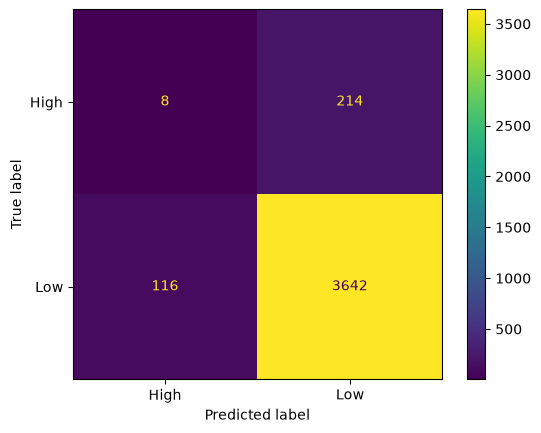

In [24]:
ConfusionMatrixDisplay.from_estimator(
    best_model, X_test, y_test, display_labels=['High', 'Low'], 
)
plt.show()

### Multiclass Classification

## Regression

### NPP Regression

### VegC Regression